In [1]:
import pandas as pd
from prophet import Prophet

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df  = pd .read_csv('gimnasio_series_temporales_horarias_clientes.csv',sep=',')

In [4]:
df.head(3)

,datetime,date,hour,day_of_week,is_weekend,is_vacation,time_band,clientes,clase_dirigida,promo,aforo_max,ocupacion_pct
0,2024-01-01 00:00:00,2024-01-01,0,0,0,0,cerrado,0.0,0,0,120,0.000000
1,2024-01-01 01:00:00,2024-01-01,1,0,0,0,cerrado,6.0,0,0,120,0.050000
2,2024-01-01 02:00:00,2024-01-01,2,0,0,0,cerrado,2.0,0,0,120,0.016667


In [25]:
len(df)

8784

In [3]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [4]:
df['y']  = df['clientes']
df['ds'] = df['datetime']

In [5]:
df_pro=df[['ds','y']]

In [26]:
def predict(data, w):
    df = data.copy().reset_index()
    for i in range(w,len(df_pro)+1):   
        s       = i-1
        df_     = df.iloc[i-w:i].reset_index()
        model    = Prophet(daily_seasonality=True)
        model.fit(df_) 
        future   = model.make_future_dataframe(periods=1, freq='5min', include_history=False)
        forecast = model.predict(future)
        last     = forecast.iloc[-1]
        
        df.at[s,'yhat'] = last.yhat
        df.at[s,'trend']= last['trend']

        df.at[s,'yhat_lower']= last['yhat_lower']
        df.at[s,'yhat_upper']= last['yhat_upper']
        
    return df

In [ ]:
df_rs =predict(df, 168)

18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1] done processing
18:38:19 - cmdstanpy - INFO - Chain [1] start processing
18:38:19 - cmdstanpy - INFO - Chain [1]

In [17]:
df_rs['dif'] = df_rs['yhat'] - df_rs['y']

In [19]:
df_rs = df_rs.dropna()

In [20]:
df_rs.dif.mean()

0.01714174622599111

In [ ]:
df_rs.groupby("hour")["dif"].mean()

In [16]:
df_rs.head(12)

,index,datetime,date,hour,day_of_week,is_weekend,is_vacation,time_band,clientes,clase_dirigida,promo,aforo_max,ocupacion_pct,y,ds,yhat,trend,yhat_lower,yhat_upper
0,0,2024-01-01 00:00:00,2024-01-01,0,0,0,0,cerrado,0.0,0,0,120,0.000000,0.0,2024-01-01 00:00:00,NaN,NaN,NaN,NaN
1,1,2024-01-01 01:00:00,2024-01-01,1,0,0,0,cerrado,6.0,0,0,120,0.050000,6.0,2024-01-01 01:00:00,NaN,NaN,NaN,NaN
2,2,2024-01-01 02:00:00,2024-01-01,2,0,0,0,cerrado,2.0,0,0,120,0.016667,2.0,2024-01-01 02:00:00,NaN,NaN,NaN,NaN
3,3,2024-01-01 03:00:00,2024-01-01,3,0,0,0,cerrado,0.0,0,0,120,0.000000,0.0,2024-01-01 03:00:00,NaN,NaN,NaN,NaN
4,4,2024-01-01 04:00:00,2024-01-01,4,0,0,0,cerrado,0.0,0,0,120,0.000000,0.0,2024-01-01 04:00:00,NaN,NaN,NaN,NaN
5,5,2024-01-01 05:00:00,2024-01-01,5,0,0,0,cerrado,10.0,0,0,120,0.083333,10.0,2024-01-01 05:00:00,NaN,NaN,NaN,NaN
6,6,2024-01-01 06:00:00,2024-01-01,6,0,0,0,mañana,25.0,0,0,120,0.208333,25.0,2024-01-01 06:00:00,NaN,NaN,NaN,NaN
7,7,2024-01-01 07:00:00,2024-01-01,7,0,0,0,mañana,37.0,1,0,120,0.308333,37.0,2024-01-01 07:00:00,NaN,NaN,NaN,NaN
8,8,2024-01-01 08:00:00,2024-01-01,8,0,0,0,mañana,48.0,1,0,120,0.400000,48.0,2024-01-01 08:00:00,NaN,NaN,NaN,NaN
9,9,2024-01-01 09:00:00,2024-01-01,9,0,0,0,mañana,35.0,0,0,120,0.291667,35.0,2024-01-01 09:00:00,40.406284,40.406284,29.116217,50.818713


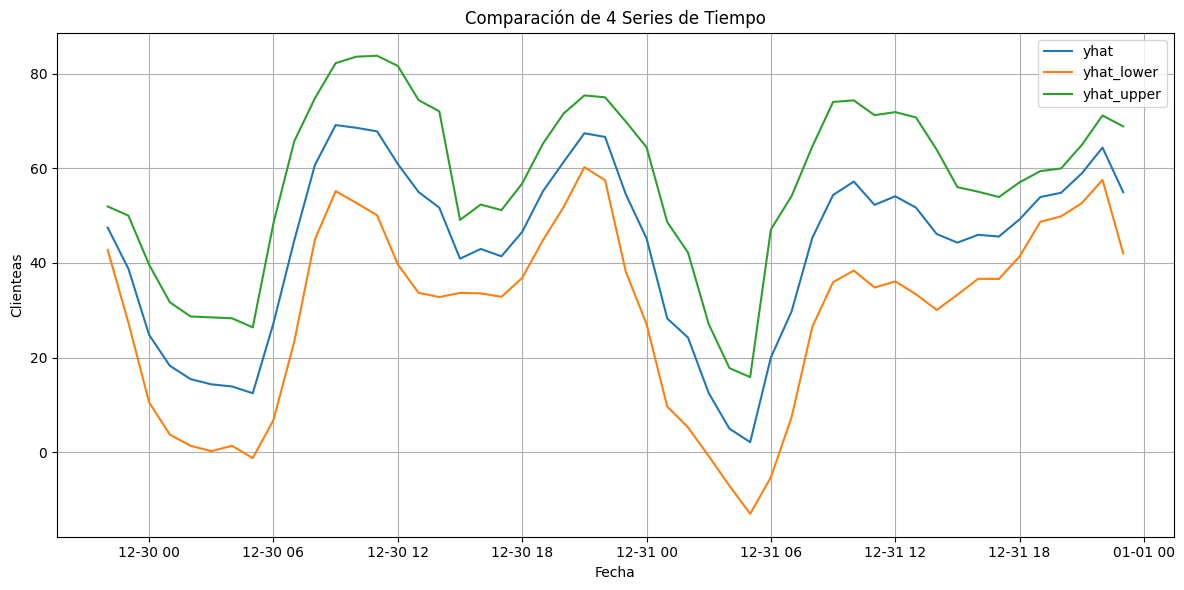

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Crear un DataFrame de ejemplo con 4 series
df_rs2=df_rs.tail(50).reset_index()

# Graficar las 4 series
plt.figure(figsize=(12, 6))
plt.plot(df_rs2['datetime'], df_rs2['yhat'], label='yhat')
plt.plot(df_rs2['datetime'], df_rs2['yhat_lower'], label='yhat_lower')
plt.plot(df_rs2['datetime'], df_rs2['yhat_upper'], label='yhat_upper')
#plt.plot(df_rs2['datetime'], df_rs2['y'], label='clientes')

# Personalización
plt.title('Comparación de 4 Series de Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Clienteas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
